# Probabilistic Matrix Factorization, end to end

A walkthrough of the model from Mnih & Salakhutdinov (NIPS 2007): the probabilistic
story, the objective that falls out of it, a from-scratch implementation short enough
to read in one screen, and the experiments that decide whether it is any good.

This notebook is the guided tour. The packaged implementation lives in `src/pmf/`,
the full experimental study in `scripts/run_experiments.py`, and the write-up in
`report/`.

**What we are predicting.** A user–item rating matrix $R$ where almost everything is
missing — 93.7% of MovieLens 100K is unobserved. The task is to fill in the blanks.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import numpy as np

from pmf import (
    BiasBaseline, BPMF, GlobalMean, ItemMean, PMF, UserMean,
    describe, load_movielens, rmse, train_val_test_split,
)
from pmf.config import tuned
from pmf.viz import PALETTE, apply_style

apply_style()
SERIES = list(PALETTE.values())

# Hyperparameters come from pmf.config, which records what the validation search
# selected, so this notebook cannot drift from the paper's numbers.
PMF_PARAMS = tuned("ml-100k", "pmf")
PMF_BIAS_PARAMS = tuned("ml-100k", "pmf_bias")
print("PMF          ", PMF_PARAMS)
print("PMF + biases ", PMF_BIAS_PARAMS)

PMF           {'n_factors': 20, 'lr': 0.0005, 'reg': 0.1, 'momentum': 0.9, 'batch_size': 256, 'n_epochs': 600, 'patience': 25}
PMF + biases  {'n_factors': 20, 'lr': 0.001, 'reg': 0.1, 'momentum': 0.9, 'batch_size': 256, 'n_epochs': 600, 'patience': 25}


## 1. The data

MovieLens 100K: 943 users, 1682 films, 100,000 ratings on a 1–5 integer scale.
Downloads on first use.

In [2]:
data = load_movielens("ml-100k")
stats = describe(data)
for key, value in stats.items():
    print(f"{key:32s} {value}")

dataset                          ml-100k
n_users                          943
n_items                          1682
n_ratings                        100000
sparsity                         0.936953
density_pct                      6.3047
rating_min                       1.0
rating_max                       5.0
rating_mean                      3.5299
rating_std                       1.1257
ratings_per_user_mean            106.04
ratings_per_user_median          65.0
ratings_per_user_min             20
ratings_per_item_mean            59.45
ratings_per_item_median          27.0
items_with_lt_5_ratings_pct      19.8
users_with_lt_20_ratings_pct     0.0


Two features of this data drive everything that follows.

**It is overwhelmingly empty.** Only 6.3% of the matrix is observed, so any method that
needs to compare full row vectors has almost nothing to compare.

**It is long-tailed.** The median user rates 65 films and the median film receives 27
ratings, but the means are 106 and 59 — a minority of heavy users and popular films
carries most of the mass. A model can post a good average error while being useless for
the tail, which is why the aggregate RMSE is broken out by user activity later.

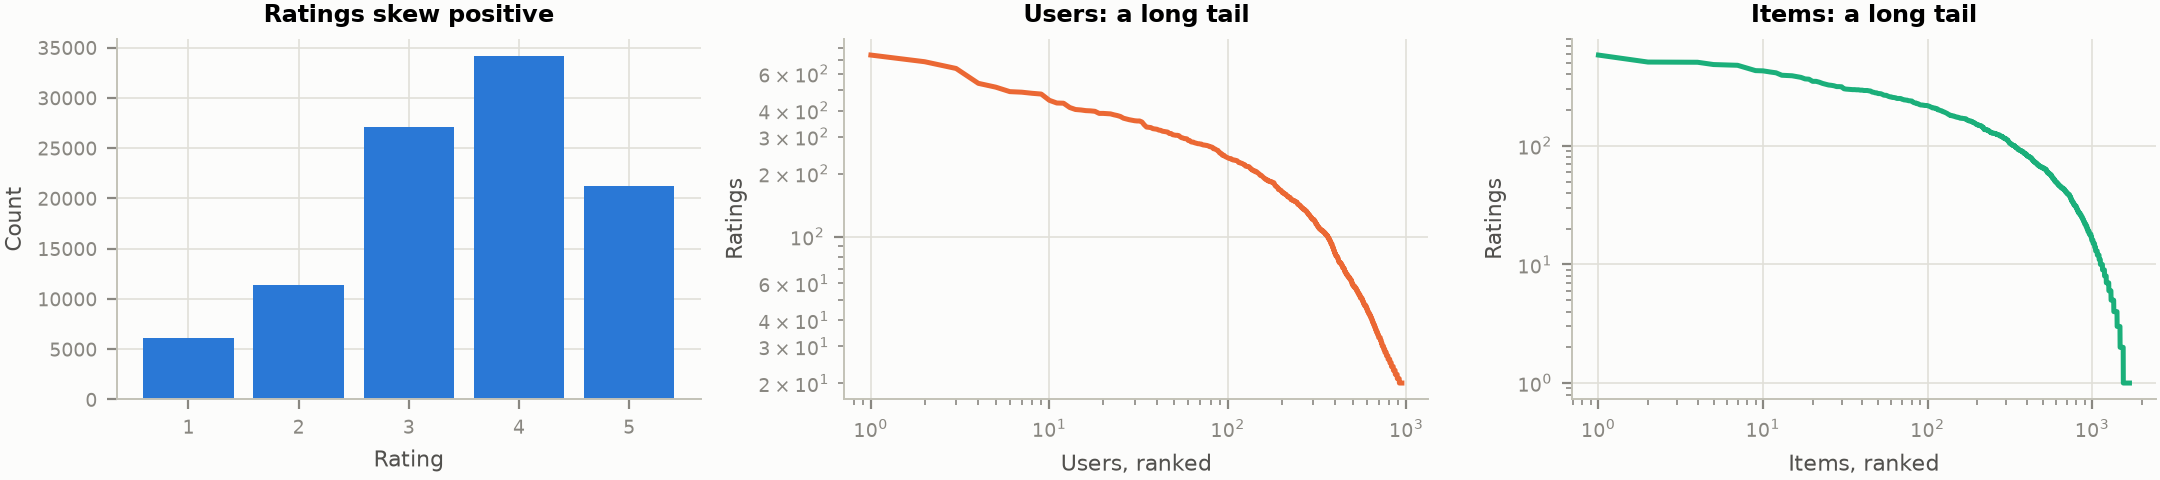

In [3]:
per_user = np.bincount(data.users)
per_item = np.bincount(data.items)

fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))
axes[0].hist(data.ratings, bins=np.arange(0.5, 6.5), color=PALETTE["blue"], rwidth=0.82, linewidth=0)
axes[0].set(xticks=[1, 2, 3, 4, 5], xlabel="Rating", ylabel="Count", title="Ratings skew positive")

for ax, counts, label, colour in (
    (axes[1], per_user, "Users", PALETTE["orange"]),
    (axes[2], per_item, "Items", PALETTE["aqua"]),
):
    ax.plot(np.arange(1, counts.size + 1), np.sort(counts)[::-1], color=colour)
    ax.set(xscale="log", yscale="log", xlabel=f"{label}, ranked", ylabel="Ratings",
           title=f"{label}: a long tail")
fig.tight_layout();

## 2. The model

Give every user a vector $u_i \in \mathbb{R}^d$ and every film a vector $v_j \in \mathbb{R}^d$,
and assume an observed rating is a noisy inner product:

$$p(R \mid U, V, \sigma^2) = \prod_{i}\prod_{j}\Big[\mathcal{N}\big(R_{ij} \mid u_i^\top v_j,\ \sigma^2\big)\Big]^{I_{ij}}$$

with $I_{ij} = 1$ when the rating is observed. Put zero-mean spherical Gaussian priors on
both factor sets, $p(U \mid \sigma_U^2) = \prod_i \mathcal{N}(u_i \mid 0, \sigma_U^2 I)$ and
likewise for $V$.

Taking $-\log$ of the posterior and dropping constants gives the thing we actually minimise:

$$E = \tfrac{1}{2}\sum_{i,j} I_{ij}\big(R_{ij} - u_i^\top v_j\big)^2
      + \tfrac{\lambda_U}{2}\lVert U\rVert_F^2 + \tfrac{\lambda_V}{2}\lVert V\rVert_F^2,
  \qquad \lambda_U = \frac{\sigma^2}{\sigma_U^2},\quad \lambda_V = \frac{\sigma^2}{\sigma_V^2}.$$

So *maximum a posteriori* PMF is exactly $L_2$-regularised squared error on the observed
entries — and the regularisation strength is a ratio of variances, not a free knob. The
gradients are one line each:

$$\frac{\partial E}{\partial u_i} = \sum_{j} I_{ij}\,(u_i^\top v_j - R_{ij})\,v_j + \lambda_U u_i,
  \qquad
  \frac{\partial E}{\partial v_j} = \sum_{i} I_{ij}\,(u_i^\top v_j - R_{ij})\,u_i + \lambda_V v_j.$$

Note the sum runs over *observed* pairs only. That is what makes a step cost
$O(|\text{observed}| \cdot d)$ rather than $O(mn \cdot d)$, and it is the whole basis of the
paper's claim to scale linearly.

### The whole algorithm, from scratch

Everything above, with no library beyond NumPy. The packaged `pmf.models.PMF` adds
early stopping, a logistic link, bias terms and a faster scatter-add, but the learning is
this:

In [4]:
def pmf_from_scratch(users, items, ratings, n_users, n_items, d=20,
                     lr=0.005, reg=0.05, n_epochs=60, seed=0):
    """MAP PMF by minibatch gradient descent. Returns (U, V, global_mean)."""
    rng = np.random.default_rng(seed)
    mu = ratings.mean()
    targets = ratings - mu                      # model the residual, so zero-mean priors make sense
    U = rng.normal(0, 0.05, (n_users, d))
    V = rng.normal(0, 0.05, (n_items, d))

    for _ in range(n_epochs):
        for batch in np.array_split(rng.permutation(users.size), 100):
            bu, bi = users[batch], items[batch]
            error = np.einsum("ij,ij->i", U[bu], V[bi]) - targets[batch]

            grad_U = error[:, None] * V[bi] + reg * U[bu]
            grad_V = error[:, None] * U[bu] + reg * V[bi]

            np.add.at(U, bu, -lr * grad_U)      # add.at, not U[bu] -= ..., so that a user
            np.add.at(V, bi, -lr * grad_V)      # appearing twice in a batch gets both updates
    return U, V, mu


split = train_val_test_split(data, val_size=0.1, test_size=0.2, seed=0)
U, V, mu = pmf_from_scratch(split.train.users, split.train.items, split.train.ratings,
                            data.n_users, data.n_items)

predicted = np.clip(np.einsum("ij,ij->i", U[split.test.users], V[split.test.items]) + mu, 1, 5)
print(f"from scratch, {U.size + V.size:,} parameters -> test RMSE {rmse(split.test.ratings, predicted):.4f}")

from scratch, 52,500 parameters -> test RMSE 0.9377


### Is the gradient right?

Hand-derived gradients are where these implementations quietly go wrong, so check the
analytic gradient against a central finite difference of the objective it claims to
descend. This is the same check the test suite runs across every variant.

In [5]:
model = PMF(n_factors=4, reg=0.3, seed=0)
model.rating_min, model.rating_max, model._span, model.global_mean = 1.0, 5.0, 4.0, 3.0
rng = np.random.default_rng(0)
model.U = rng.normal(0, 0.5, (6, 4))
model.V = rng.normal(0, 0.5, (8, 4))
model.b_user, model.b_item = np.zeros(6), np.zeros(8)

u_idx, i_idx = rng.integers(0, 6, 30), rng.integers(0, 8, 30)
targets = rng.normal(0, 1, 30)
analytic = model.gradients(u_idx, i_idx, targets, n_total=30)[0]

eps, numeric = 1e-6, np.zeros_like(model.U)
for index in np.ndindex(*model.U.shape):
    original = model.U[index]
    model.U[index] = original + eps
    plus = model._objective(u_idx, i_idx, targets)
    model.U[index] = original - eps
    numeric[index] = (plus - model._objective(u_idx, i_idx, targets)) / (2 * eps)
    model.U[index] = original

print(f"max |analytic - numeric| = {np.abs(analytic - numeric).max():.3e}")

max |analytic - numeric| = 2.220e-09


## 3. Training, and the thing that goes wrong

Two series matter and they are *not* the same series: the MAP objective $E$ (which
includes the penalty and should fall monotonically) and the unpenalised RMSE (which is
the actual quality measure). Reporting a blend of the two — as the implementation this
project forked did — makes the learning curve uninterpretable.

objective monotone decreasing: True


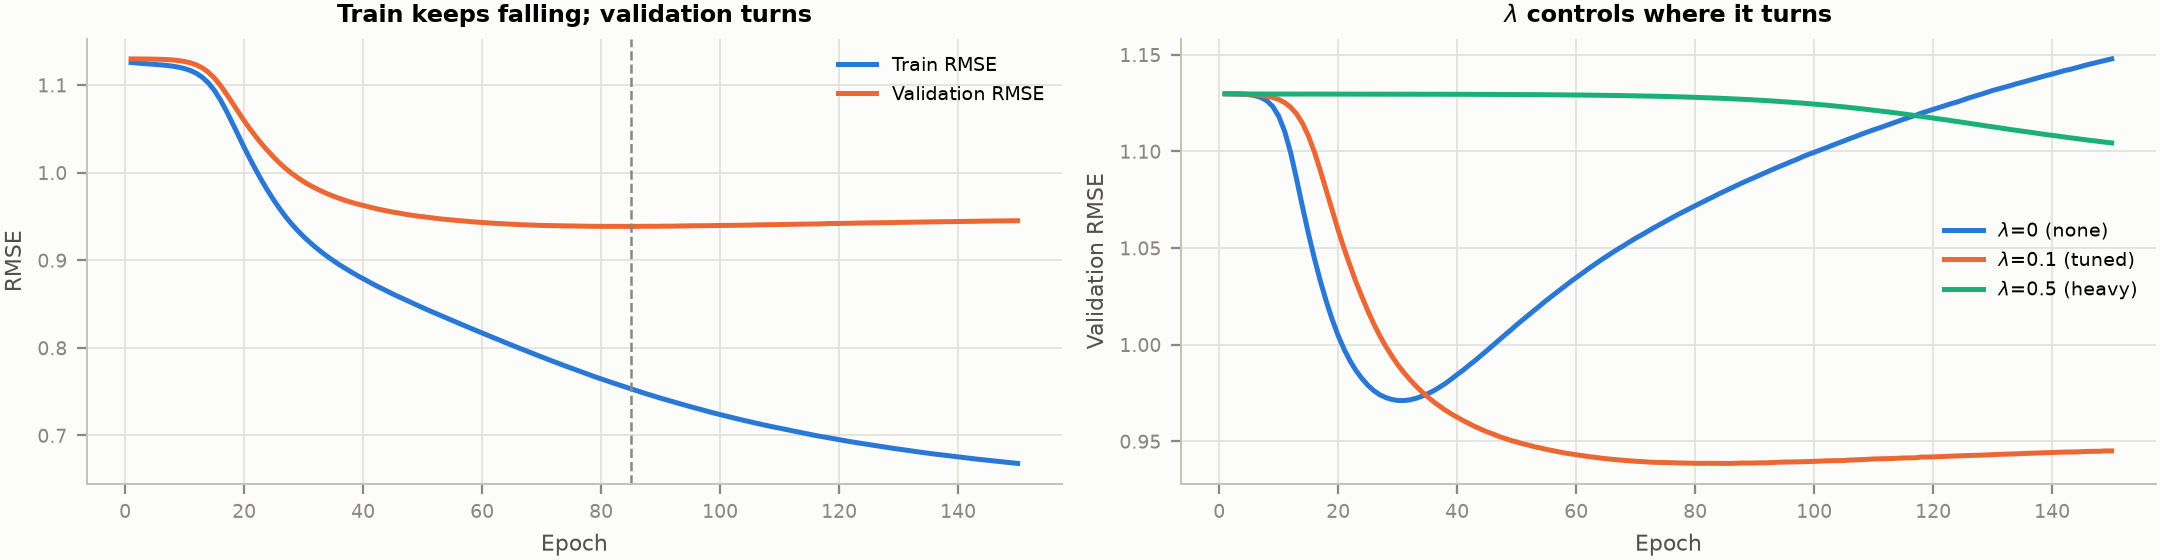

In [6]:
traces = {}
base = {**PMF_PARAMS, "n_factors": 30, "n_epochs": 150}

for label, reg in [("$\\lambda$=0 (none)", 0.0), ("$\\lambda$=0.1 (tuned)", 0.1),
                   ("$\\lambda$=0.5 (heavy)", 0.5)]:
    fitted = PMF(seed=0, early_stopping=False, **{**base, "reg": reg}).fit(split.train, split.val)
    traces[label] = fitted.history.as_dict()

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
tuned_trace = traces["$\\lambda$=0.1 (tuned)"]
axes[0].plot(tuned_trace["epoch"], tuned_trace["train_rmse"], color=PALETTE["blue"], label="Train RMSE")
axes[0].plot(tuned_trace["epoch"], tuned_trace["val_rmse"], color=PALETTE["orange"], label="Validation RMSE")
best = int(np.argmin(tuned_trace["val_rmse"]))
axes[0].axvline(best + 1, color="#898781", ls="--", lw=0.9)
axes[0].set(xlabel="Epoch", ylabel="RMSE", title="Train keeps falling; validation turns")
axes[0].legend()

for colour, (label, trace) in zip(SERIES, traces.items()):
    axes[1].plot(trace["epoch"], trace["val_rmse"], color=colour, label=label)
axes[1].set(xlabel="Epoch", ylabel="Validation RMSE", title="$\\lambda$ controls where it turns")
axes[1].legend()
fig.tight_layout()

print(f"objective monotone decreasing: {np.all(np.diff(tuned_trace['objective']) < 1e-6)}")

The left panel is the whole argument for early stopping: training error falls forever
while held-out error bottoms out and climbs. The right panel shows $\lambda$ moving that
turning point — with $\lambda = 0$ the model memorises almost immediately.

## 4. Is it actually good? Baselines first

An RMSE means nothing on its own. Before believing any factorisation result, establish
what trivial models achieve on the same split — predicting the global mean, the user's
mean, the item's mean, and shrunk additive user+item offsets.

In [7]:
contenders = {
    "Global mean": GlobalMean(),
    "User mean": UserMean(),
    "Item mean": ItemMean(),
    "Bias baseline": BiasBaseline(damping=10.0),
    "PMF (d=20)": PMF(seed=0, **PMF_PARAMS),
    "PMF + biases": PMF(seed=0, use_bias=True, **PMF_BIAS_PARAMS),
    "BPMF (Gibbs)": BPMF(n_factors=20, n_iter=120, burn_in=25, seed=0),
}

scores = {}
for label, contender in contenders.items():
    contender.fit(split.train, split.val)
    scores[label] = rmse(split.test.ratings, contender.predict_data(split.test))
    print(f"{label:16s} {scores[label]:.4f}")

Global mean      1.1218
User mean        1.0366
Item mean        1.0254
Bias baseline    0.9421


PMF (d=20)       0.9309


PMF + biases     0.9116


BPMF (Gibbs)     0.9069


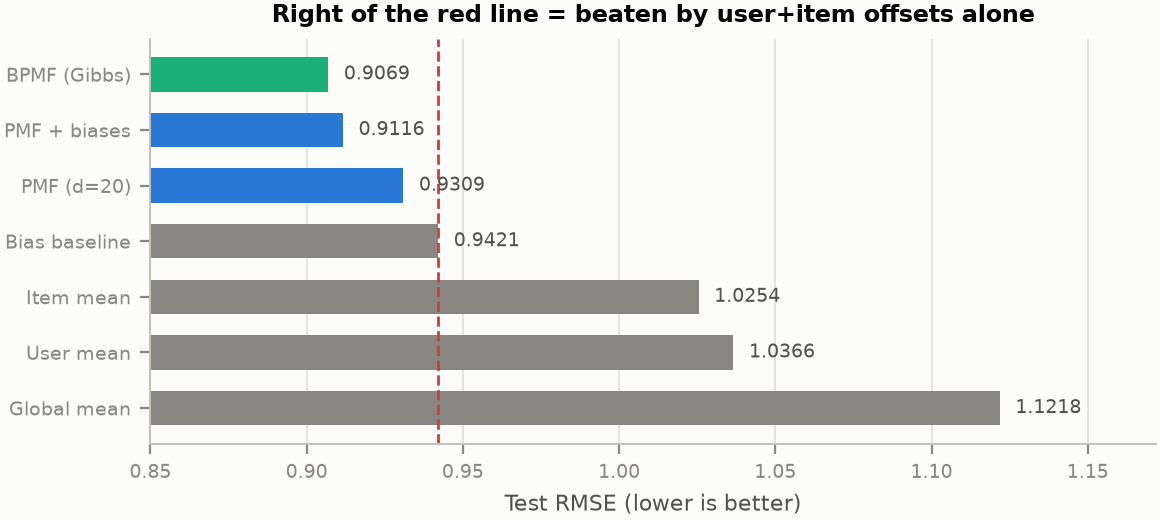

In [8]:
order = sorted(scores, key=scores.get, reverse=True)
values = [scores[k] for k in order]
colours = ["#898781" if "mean" in k or "Bias" in k else PALETTE["blue"] for k in order]
colours[int(np.argmin(values))] = PALETTE["aqua"]

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.barh(order, values, color=colours, height=0.62, linewidth=0)
for y, v in enumerate(values):
    ax.text(v + 0.005, y, f"{v:.4f}", va="center", fontsize=7, color="#52514e")

# The bar to clear is the bias baseline: the best model containing no factorisation.
ax.axvline(scores["Bias baseline"], color="#d03b3b", ls="--", lw=1)
ax.set(xlim=(0.85, max(values) + 0.05), xlabel="Test RMSE (lower is better)",
       title="Right of the red line = beaten by user+item offsets alone")
ax.grid(axis="y", visible=False)
fig.tight_layout();

## 5. How much capacity, and how much shrinkage?

The two hyperparameters that matter. Note that $d$ and $\lambda$ interact: raising $d$
without raising $\lambda$ buys nothing but overfitting.

d=  2  test 0.9496  (no early stop 0.9613)


d=  5  test 0.9371  (no early stop 0.9376)


d= 10  test 0.9339  (no early stop 0.9374)


d= 20  test 0.9309  (no early stop 0.9378)


d= 30  test 0.9349  (no early stop 0.9417)


d= 50  test 0.9334  (no early stop 0.9380)


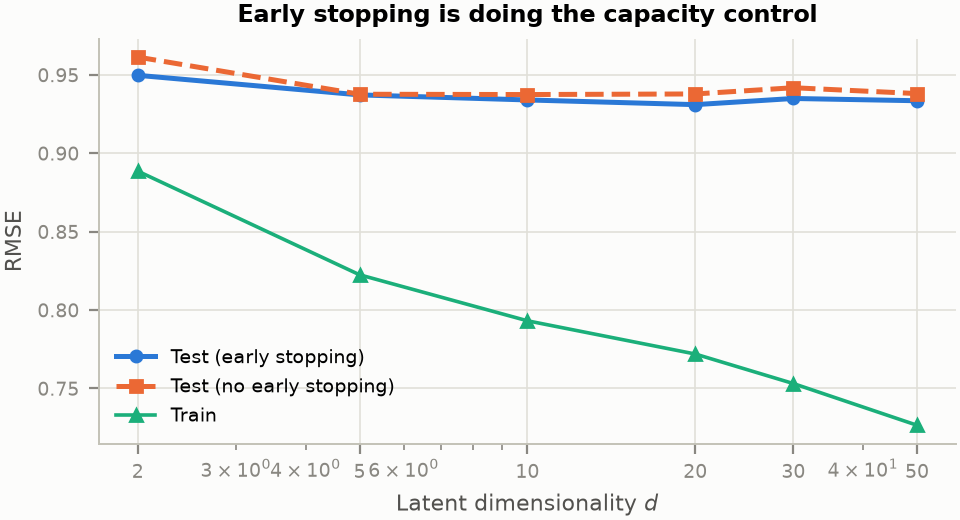

In [9]:
dims = [2, 5, 10, 20, 30, 50]
by_dim = {"stopped": [], "unstopped": [], "train": []}
sweep = {k: v for k, v in PMF_PARAMS.items() if k != "n_factors"}

for d in dims:
    stopped = PMF(n_factors=d, seed=0, **sweep).fit(split.train, split.val)
    running = PMF(n_factors=d, seed=0, early_stopping=False,
                  **{**sweep, "n_epochs": 150}).fit(split.train, split.val)
    by_dim["stopped"].append(rmse(split.test.ratings, stopped.predict_data(split.test)))
    by_dim["unstopped"].append(rmse(split.test.ratings, running.predict_data(split.test)))
    by_dim["train"].append(rmse(split.train.ratings, stopped.predict_data(split.train)))
    print(f"d={d:3d}  test {by_dim['stopped'][-1]:.4f}  (no early stop {by_dim['unstopped'][-1]:.4f})")

fig, ax = plt.subplots(figsize=(5, 2.8))
ax.plot(dims, by_dim["stopped"], "o-", color=PALETTE["blue"], label="Test (early stopping)")
ax.plot(dims, by_dim["unstopped"], "s--", color=PALETTE["orange"], label="Test (no early stopping)")
ax.plot(dims, by_dim["train"], "^-", color=PALETTE["aqua"], lw=1.3, label="Train")
ax.set(xscale="log", xticks=dims, xlabel="Latent dimensionality $d$", ylabel="RMSE",
       title="Early stopping is doing the capacity control")
ax.set_xticklabels(dims)
ax.legend()
fig.tight_layout();

## 6. Where the error actually lives

The aggregate RMSE hides the users the model serves worst. Breaking test error down by
how many training ratings each user has shows where a Bayesian treatment earns its keep.

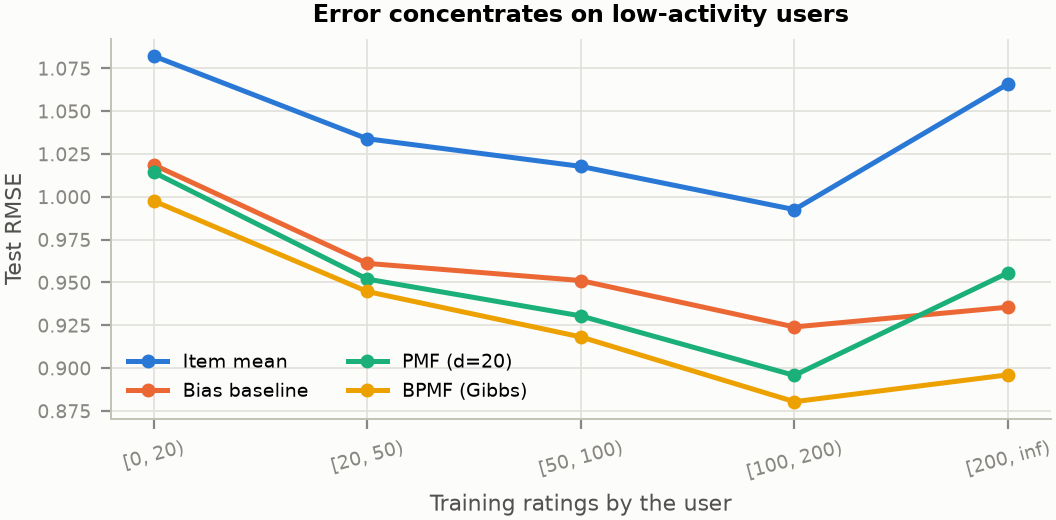

In [10]:
from pmf.metrics import rmse_by_group

bins = [(0, 20), (20, 50), (50, 100), (100, 200), (200, np.inf)]
activity = np.bincount(split.train.users, minlength=data.n_users)[split.test.users]

fig, ax = plt.subplots(figsize=(5.5, 2.8))
for colour, label in zip(SERIES, ["Item mean", "Bias baseline", "PMF (d=20)", "BPMF (Gibbs)"]):
    rows = rmse_by_group(split.test.ratings, contenders[label].predict_data(split.test), activity, bins)
    ax.plot([r["bin"] for r in rows], [r["rmse"] for r in rows], "o-", color=colour, label=label)

ax.set(xlabel="Training ratings by the user", ylabel="Test RMSE",
       title="Error concentrates on low-activity users")
ax.tick_params(axis="x", labelrotation=15)
ax.legend(ncol=2, fontsize=7)
fig.tight_layout();

## 7. Does it recommend anything sensible?

RMSE is a proxy. The deliverable is a ranked list, so look at one.

In [11]:
best_model = contenders["PMF + biases"]
titles = data.titles
user = int(np.argmax(np.bincount(split.train.users)))   # the most prolific rater

seen = set(split.train.items[split.train.users == user])
scores_all = best_model.score_all_items(user, data.n_items)
scores_all[list(seen)] = -np.inf

liked = split.train.items[(split.train.users == user) & (split.train.ratings == 5)][:5]
print(f"user {user} rated {len(seen)} films. Some they gave 5/5:")
for item in liked:
    print(f"   {titles.get(int(item), '?')}")

print("\ntop-10 recommendations from unseen films:")
for rank, item in enumerate(np.argsort(-scores_all)[:10], 1):
    print(f"  {rank:2d}. {titles.get(int(item), '?'):48s} {scores_all[item]:.3f}")

user 404 rated 523 films. Some they gave 5/5:
   Indiana Jones and the Last Crusade (1989)
   American President, The (1995)
   Blues Brothers, The (1980)
   Empire Strikes Back, The (1980)
   Godfather, The (1972)

top-10 recommendations from unseen films:
   1. It's a Wonderful Life (1946)                     3.585
   2. Back to the Future (1985)                        3.427
   3. Fugitive, The (1993)                             3.390
   4. Affair to Remember, An (1957)                    3.376
   5. Jerry Maguire (1996)                             3.344
   6. Pather Panchali (1955)                           3.341
   7. Die Hard (1988)                                  3.340
   8. One Flew Over the Cuckoo's Nest (1975)           3.334
   9. Prefontaine (1997)                               3.331
  10. Aladdin (1992)                                   3.268


## 8. What this replaces

This project re-executes a 2025 report that put PMF's MovieLens 100K test RMSE at
**1.0109**. Two checks put that number in context.

In [12]:
claimed = 1.0109
print(f"originally reported          {claimed:.4f}")
print(f"item-mean baseline           {scores['Item mean']:.4f}   <- no factorisation at all")
print(f"bias baseline                {scores['Bias baseline']:.4f}   <- user+item offsets, closed form")
print(f"PMF, tuned                   {scores['PMF (d=20)']:.4f}")
print(f"PMF + biases, tuned          {scores['PMF + biases']:.4f}")

gap = claimed - scores["Bias baseline"]
print(f"\nthe reported figure trails the bias baseline by {gap:+.4f} RMSE,")
print(f"and improves on a per-item average by only {scores['Item mean'] - claimed:+.4f}.")
print("A factorisation that cannot beat additive offsets has not shown its")
print("latent structure is contributing anything.")

originally reported          1.0109
item-mean baseline           1.0254   <- no factorisation at all
bias baseline                0.9421   <- user+item offsets, closed form
PMF, tuned                   0.9309
PMF + biases, tuned          0.9116

the reported figure trails the bias baseline by +0.0688 RMSE,
and improves on a per-item average by only +0.0145.
A factorisation that cannot beat additive offsets has not shown its
latent structure is contributing anything.


## Where to go next

- `scripts/run_experiments.py` — the full study: multi-seed confidence intervals,
  ML-1M, ranking metrics, the scalability regression, and the claim audit.
- `report/main.tex` — the rewritten IEEE paper.
- `site/index.html` — the interactive summary, including a PMF that trains in the browser.
- `legacy/` — the original forked implementation, preserved with its defects documented.